# BTCUSDC Order-Flow Study: Return, Covariance, And Correlation Scaling

This notebook studies how a raw order-flow signal lines up with later price moves on the `BTCUSDC / 20260223` trade stream.

We use the same generalized imbalance signal as notebook 02, but we now separate two horizons:

- `T_signal`: the number of past trades used to build the imbalance signal,
- `H_return`: the future horizon used to measure the price move.

The notebook starts with the paper-style same-horizon comparison, where `T_signal = H_return = common_horizon` in trade time. It then adds two more readable grids:

- event-time signal versus trade-time future returns,
- event-time signal versus clock-time future returns.

The two main questions are:

- does the signal move with price in raw units,
- does that relationship remain strong after normalization.

## Plain-Language Guide

This notebook is written for readers who may not have market microstructure background.

- `BTCUSDC` means Bitcoin traded against USD Coin.
- `midprice` means the average of the best bid and best ask in the order book.
- `order-flow signal` means a signed running sum of trades, where buyer-initiated trades count positive and seller-initiated trades count negative.
- `future return` means the log price change from now to a later point. For small moves this is close to a percentage return.
- `T_signal` means the number of past trades used to build the signal.
- `H_return` means the future horizon used to measure the later price move.
- `trade-time horizon` means the return is measured after a fixed number of future trades.
- `clock-time horizon` means the return is measured after a fixed amount of wall-clock time, such as `30s` or `5min`.
- `common_horizon` means we set `T_signal` and trade-time `H_return` to the same trade count for the first comparison.
- `a` controls how strongly large trades are weighted. `a = 0` uses only trade direction, while larger `a` values give more weight to large trade size.
- `UTC` means Coordinated Universal Time, the timezone used in the summary table below.

## What Covariance Means

`E[Delta_H * I_{T_signal}^a]` measures raw co-movement between future price changes and the imbalance signal.

Interpretation:

- positive values mean buy-heavy signals tend to line up with upward price moves,
- negative values mean the opposite,
- values near zero mean weak linear coupling.

This is useful because it keeps the original scale of the two variables, so it shows how much joint movement we see before any normalization.

Caveat:

- if one variable is rescaled, covariance changes,
- so covariance is informative, but it is not directly comparable across all horizon choices without context.


## What Correlation Means

Correlation is the normalized version of the same coupling.

We report two versions:

- Pearson correlation: linear co-movement on the raw values,
- Spearman correlation: rank-based co-movement on the raw values.

Interpretation:

- `+1` means strong positive association,
- `0` means no monotone or linear relationship,
- `-1` means strong negative association.

Why we need both:

- Pearson is sensitive to linear scale,
- Spearman is more robust when the relationship is monotone but not perfectly linear,
- together they tell us whether the signal/return link is a linear effect or just an ordered effect.

So the notebook uses both:

- covariance for raw coupling,
- Pearson correlation for linear normalization,
- Spearman correlation for rank-based normalization.

## Why Both Matter Together

Covariance answers: "How much joint movement is there in native units?"

Pearson correlation answers: "Is the relationship still strong after we remove scale in a linear way?"

Spearman correlation answers: "Is the ordering of large and small values still aligned, even if the relationship is not linear?"

That distinction matters because a large covariance can come from a large signal scale, while Pearson and Spearman tell us whether the price and signal link is genuinely strong across horizons and weighting choices.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from stats.features import make_trade_frame
from stats.notebook import load_orderflow_day


In [2]:
EXCHANGE = "binance"
SYMBOL = "BTCUSDC"
REFERENCE_DAY = "20260223"
REPLAY_ON_GAP = "skip-segment"

dataset, trades, top, replay_info = load_orderflow_day(
    day=REFERENCE_DAY,
    symbol=SYMBOL,
    exchange=EXCHANGE,
    replay_on_gap=REPLAY_ON_GAP,
)

day_dir = dataset.day_dir
day_dir


PosixPath('/Users/hoangdeveloper/PycharmProjects/exchange-data-backtester')

## Planned Computations

The implementation compares the future return `Delta_H` and the imbalance signal `I_{T_signal}^a` in three passes.

Main outputs:

- a scatter plot of raw signal versus future return for one representative case,
- the original same-horizon trade-time covariance/correlation grid,
- a decoupled trade-time grid over `(T_signal, H_return_trades)`,
- a clock-time grid over `(T_signal, H_return_clock)`,
- heatmaps and compact best-correlation tables for Pearson and Spearman.

The signal remains event-time based in this notebook. That means `T_signal` always counts trades, while the return horizon can be either future trades or future clock time.

## Horizon Convention

There are two horizons in principle:

- `T_signal`: the number of past trades used in the imbalance signal,
- `H_return`: the future horizon used in the return.

The first comparison keeps the old paper-style convention:

- `I_{T_signal}^a` uses the last `common_horizon` trades,
- `Delta_H` uses the next `common_horizon` trades,
- therefore `T_signal = H_return = common_horizon`.

The later sections decouple the two horizons:

- trade-time returns: `Delta_H(t) = log(mid_{t+H}) - log(mid_t)`,
- clock-time returns: `Delta_h(t) = log(mid_{time(t)+h}) - log(mid_t)`.

This lets us ask whether a signal built from the last `N` trades is more related to the next `N` trades or to the next `30s`, `5min`, or `60min`.

In [3]:
from stats.io import load_day
from stats.notebook import replay_summary
from stats.tables import get_or_build_top_of_book_table, get_or_build_trades_table


symbol = "PEPEUSDC"
day = "20260226"
day_dir = resolve_day_dir(PROJECT_ROOT, symbol=symbol, day=day)

dataset = load_day(day_dir)
trades = get_or_build_trades_table(dataset)
top = get_or_build_top_of_book_table(dataset, on_gap="skip-segment")
replay_info = replay_summary(dataset, replay_on_gap="skip-segment")

day_dir


PosixPath('/Users/hoangdeveloper/PycharmProjects/exchange-data-recorder/data/binance/PEPEUSDC/20260226')

In [4]:
trade_frame = make_trade_frame(trades, top, include_log_mid=True, include_trade_idx=True)
trade_frame.head()


,ts,qty,aggr_sign,price,mid_at_book,trade_idx,log_mid
0,2026-02-26 01:00:12.314000+00:00,1186440.0,1.0,0.000004,0.000004,0,-12.398445
1,2026-02-26 01:00:15.748000+00:00,1185313.0,-1.0,0.000004,0.000004,1,-12.398445
2,2026-02-26 01:00:25.736000+00:00,1162227.0,1.0,0.000004,0.000004,2,-12.398445
3,2026-02-26 01:00:28.208000+00:00,67518008.0,-1.0,0.000004,0.000004,3,-12.398445
4,2026-02-26 01:00:29.647000+00:00,1161123.0,-1.0,0.000004,0.000004,4,-12.398445


In [5]:
T_list = np.array([5, 10, 20, 50, 100, 200, 500], dtype=int)
a_list = np.array([0.0, 0.1, 0.2, 0.3, 0.5, 1.0, 1.5, 2.0], dtype=float)

SIGNAL_T_LIST = np.array([20, 50, 100, 200, 500], dtype=int)
RETURN_H_TRADE_LIST = np.array([20, 50, 100, 200, 500, 1000], dtype=int)
RETURN_H_CLOCK_LIST = ["1s", "2s", "5s", "10s", "15s", "30s", "1min", "5min", "15min", "30min", "60min"]
GRID_A_LIST = np.array([0.0, 0.3, 1.0], dtype=float)
DEFAULT_PLOT_A = 0.0

sign = trade_frame["aggr_sign"].to_numpy(dtype=float)
qty = trade_frame["qty"].to_numpy(dtype=float)
mid = trade_frame["mid_at_book"].to_numpy(dtype=float)
book_mid_frame = top[["ts", "mid"]].dropna().sort_values("ts").reset_index(drop=True)
book_mid_frame["log_mid"] = np.log(book_mid_frame["mid"])

summary = pd.Series({
    "rows_after_alignment": len(trade_frame),
    "trade_start_utc": trade_frame["ts"].min(),
    "trade_end_utc": trade_frame["ts"].max(),
    "mid_start": trade_frame["mid_at_book"].min(),
    "mid_end": trade_frame["mid_at_book"].max(),
    "segments_total": replay_info["segments_total"],
    "segments_kept": replay_info["segments_kept"],
})

display(summary.to_frame("value"))
display(trade_frame[["ts", "qty", "aggr_sign", "mid_at_book", "trade_idx"]].head())

,value
rows_after_alignment,25759
trade_start_utc,2026-02-26 01:00:12.314000+00:00
trade_end_utc,2026-02-26 23:13:54.732000+00:00
mid_start,0.000004
mid_end,0.000004
segments_total,2
segments_kept,2


,ts,qty,aggr_sign,mid_at_book,trade_idx
0,2026-02-26 01:00:12.314000+00:00,1186440.0,1.0,0.000004,0
1,2026-02-26 01:00:15.748000+00:00,1185313.0,-1.0,0.000004,1
2,2026-02-26 01:00:25.736000+00:00,1162227.0,1.0,0.000004,2
3,2026-02-26 01:00:28.208000+00:00,67518008.0,-1.0,0.000004,3
4,2026-02-26 01:00:29.647000+00:00,1161123.0,-1.0,0.000004,4


## Return Construction

For each trade index `t`, the trade-time forward log return over horizon `H_return` is:

`Delta_H(t) = log(mid_{t+H_return}) - log(mid_t)`

The clock-time forward log return over horizon `h` is:

`Delta_h(t) = log(mid(time(t) + h)) - log(mid_t)`

where the future mid is the first available top-of-book midprice at or after `time(t) + h`.

The imbalance window stays backward-looking: `I_{T_signal}^a(t)` uses the last `T_signal` trades up to `t`.

In [6]:
def _datetime_ns(values: pd.Series) -> np.ndarray:
    return pd.to_datetime(values, utc=True).astype("int64").to_numpy()


def build_trade_time_delta(trade_frame: pd.DataFrame, return_H: int) -> np.ndarray:
    log_mid = trade_frame["log_mid"].to_numpy(dtype=float)
    delta = np.full(len(log_mid), np.nan, dtype=float)
    if len(log_mid) > return_H:
        delta[:-return_H] = log_mid[return_H:] - log_mid[:-return_H]
    return delta


def build_clock_time_delta(trade_frame: pd.DataFrame, book_mid_frame: pd.DataFrame, return_horizon: str | pd.Timedelta) -> np.ndarray:
    horizon = pd.to_timedelta(return_horizon)
    trade_ts_ns = _datetime_ns(trade_frame["ts"])
    book_ts_ns = _datetime_ns(book_mid_frame["ts"])
    book_log_mid = book_mid_frame["log_mid"].to_numpy(dtype=float)

    target_ts_ns = trade_ts_ns + int(horizon.value)
    future_idx = np.searchsorted(book_ts_ns, target_ts_ns, side="left")
    valid = future_idx < len(book_log_mid)

    delta = np.full(len(trade_frame), np.nan, dtype=float)
    current_log_mid = trade_frame["log_mid"].to_numpy(dtype=float)
    delta[valid] = book_log_mid[future_idx[valid]] - current_log_mid[valid]
    return delta


def build_signal_return_frame(trade_frame: pd.DataFrame, signal_T: int, a: float, delta: np.ndarray) -> pd.DataFrame:
    sign = trade_frame["aggr_sign"].to_numpy(dtype=float)
    qty = trade_frame["qty"].to_numpy(dtype=float)
    imbalance = build_imbalance_series(sign, qty, T=signal_T, a=a)
    return pd.DataFrame({"I": imbalance, "delta": delta}).dropna().copy()


def summarize_signal_delta(imbalance: np.ndarray, delta: np.ndarray) -> pd.Series:
    x = np.asarray(imbalance, dtype=float)
    y = np.asarray(delta, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) == 0:
        return pd.Series({"cov": np.nan, "pearson": np.nan, "spearman": np.nan, "corr": np.nan, "n": 0})

    cov = float(np.mean((x - x.mean()) * (y - y.mean())))
    pearson = float(np.corrcoef(x, y)[0, 1]) if len(x) > 1 and np.std(x) > 0 and np.std(y) > 0 else np.nan

    x_rank = pd.Series(x).rank(method="average").to_numpy(dtype=float)
    y_rank = pd.Series(y).rank(method="average").to_numpy(dtype=float)
    spearman = float(np.corrcoef(x_rank, y_rank)[0, 1]) if len(x) > 1 and np.std(x_rank) > 0 and np.std(y_rank) > 0 else np.nan

    return pd.Series({"cov": cov, "pearson": pearson, "spearman": spearman, "corr": pearson, "n": len(x)})


def build_imbalance_for_signal(trade_frame: pd.DataFrame, signal_T: int, a: float) -> np.ndarray:
    sign = trade_frame["aggr_sign"].to_numpy(dtype=float)
    qty = trade_frame["qty"].to_numpy(dtype=float)
    return build_imbalance_series(sign, qty, T=signal_T, a=a)


def build_cov_corr_frame(trade_frame: pd.DataFrame, signal_T: int, return_H: int, a: float) -> pd.DataFrame:
    delta = build_trade_time_delta(trade_frame, return_H=return_H)
    return build_signal_return_frame(trade_frame, signal_T=signal_T, a=a, delta=delta)


def build_clock_cov_corr_frame(
    trade_frame: pd.DataFrame,
    book_mid_frame: pd.DataFrame,
    signal_T: int,
    return_horizon: str | pd.Timedelta,
    a: float,
) -> pd.DataFrame:
    delta = build_clock_time_delta(trade_frame, book_mid_frame=book_mid_frame, return_horizon=return_horizon)
    return build_signal_return_frame(trade_frame, signal_T=signal_T, a=a, delta=delta)


def summarize_cov_corr(frame: pd.DataFrame) -> pd.Series:
    return summarize_signal_delta(frame["I"].to_numpy(dtype=float), frame["delta"].to_numpy(dtype=float))


def return_horizon_label(value: str | pd.Timedelta) -> str:
    horizon = pd.to_timedelta(value)
    if horizon < pd.Timedelta(minutes=1):
        return f"{int(horizon.total_seconds())}s"
    if horizon < pd.Timedelta(hours=1):
        return f"{int(horizon.total_seconds() // 60)}min"
    return f"{int(horizon.total_seconds() // 3600)}h"


demo_signal_T = 10
demo_return_H = 20
demo_a = 0.2
demo_frame = build_cov_corr_frame(trade_frame, signal_T=demo_signal_T, return_H=demo_return_H, a=demo_a)
display(demo_frame.head())
display(summarize_cov_corr(demo_frame).to_frame("value"))

,I,delta
9,-44.722355,0.0
10,-77.460078,0.0
11,-75.606540,0.0
12,-118.095661,0.0
13,-60.405475,0.0


,value
cov,0.068176
pearson,0.240706
spearman,0.246440
corr,0.240706
n,25730.000000


## Raw Signal Versus Future Return

The next plot uses one concrete choice, `T_signal = 10` trades, `H_return = 10` trades, and `a = 0.3`, so the relationship is easier to see before we move to full grids.

Each point is one anchor trade:

- the horizontal axis is the raw imbalance signal built from the last `10` trades,
- the vertical axis is the future log return over the next `10` trades.

The scatter plot uses a random sample of points so the cloud stays visible. The right-hand panel groups the signal into equal-count buckets and shows the average future return in each bucket.


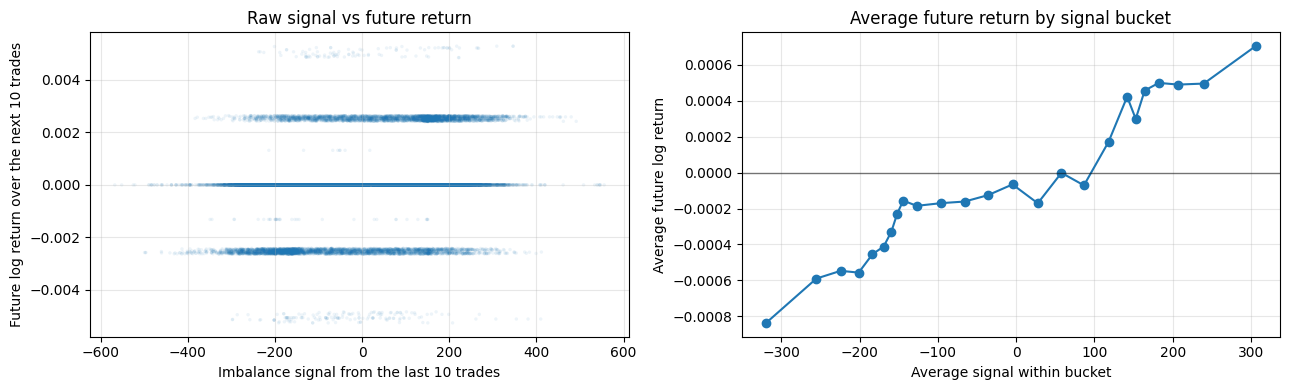

In [7]:
scatter_frame = build_cov_corr_frame(trade_frame, signal_T=demo_signal_T, return_H=demo_return_H, a=demo_a)

plot_sample_n = min(20000, len(scatter_frame))
plot_sample = scatter_frame.sample(plot_sample_n, random_state=7).sort_values("I")

bucket_view = (
    plot_sample.assign(signal_bucket=pd.qcut(plot_sample["I"], q=25, duplicates="drop"))
    .groupby("signal_bucket", observed=False)
    .agg(signal_mean=("I", "mean"), future_return_mean=("delta", "mean"), point_count=("delta", "size"))
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(plot_sample["I"], plot_sample["delta"], s=6, alpha=0.08, edgecolors="none")
axes[0].set_title("Raw signal vs future return")
axes[0].set_xlabel("Imbalance signal from the last 10 trades")
axes[0].set_ylabel("Future log return over the next 10 trades")
axes[0].grid(True, alpha=0.3)

axes[1].plot(bucket_view["signal_mean"], bucket_view["future_return_mean"], marker="o")
axes[1].axhline(0.0, color="black", linewidth=1, alpha=0.5)
axes[1].set_title("Average future return by signal bucket")
axes[1].set_xlabel("Average signal within bucket")
axes[1].set_ylabel("Average future log return")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [8]:
common_horizon_list = T_list.copy()
grid_rows = []

for a in a_list:
    for common_horizon in common_horizon_list:
        frame = build_cov_corr_frame(
            trade_frame,
            signal_T=int(common_horizon),
            return_H=int(common_horizon),
            a=float(a),
        )
        summary_row = summarize_cov_corr(frame)
        grid_rows.append({
            "a": float(a),
            "common_horizon": int(common_horizon),
            "signal_T": int(common_horizon),
            "return_H": int(common_horizon),
            "cov": float(summary_row["cov"]),
            "corr": float(summary_row["corr"]),
            "n": int(summary_row["n"]),
        })

grid_df = pd.DataFrame(grid_rows)
display(grid_df.head())


,a,common_horizon,signal_T,return_H,cov,corr,n
0,0.0,5,5,5,0.001686,0.316347,25750
1,0.0,10,10,10,0.002477,0.221824,25740
2,0.0,20,20,20,0.003432,0.152777,25720
3,0.0,50,50,50,0.003630,0.059384,25660
4,0.0,100,100,100,0.008453,0.062277,25560


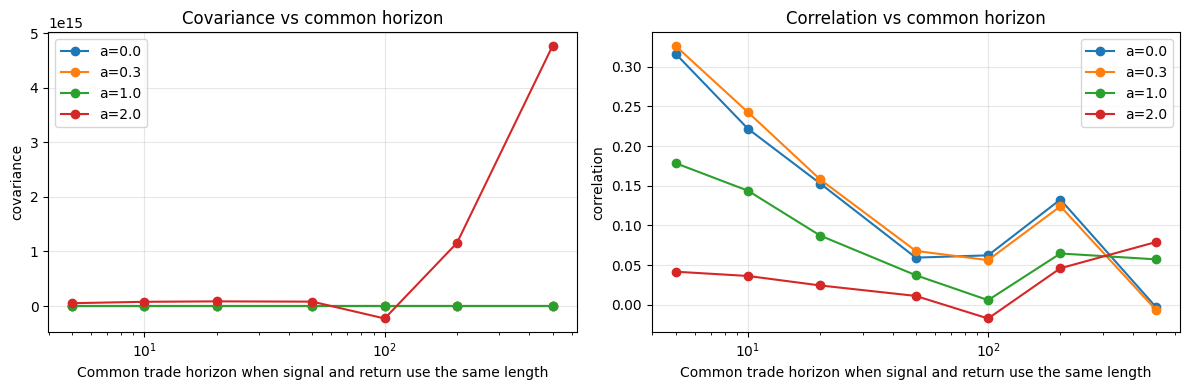

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for a in [0.0, 0.3, 1.0, 2.0]:
    tmp = grid_df[grid_df["a"] == a].sort_values("common_horizon")
    axes[0].plot(tmp["common_horizon"], tmp["cov"], marker="o", label=f"a={a}")
    axes[1].plot(tmp["common_horizon"], tmp["corr"], marker="o", label=f"a={a}")

axes[0].set_xscale("log")
axes[0].set_title("Covariance vs common horizon")
axes[0].set_xlabel("Common trade horizon when signal and return use the same length")
axes[0].set_ylabel("covariance")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xscale("log")
axes[1].set_title("Correlation vs common horizon")
axes[1].set_xlabel("Common trade horizon when signal and return use the same length")
axes[1].set_ylabel("correlation")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


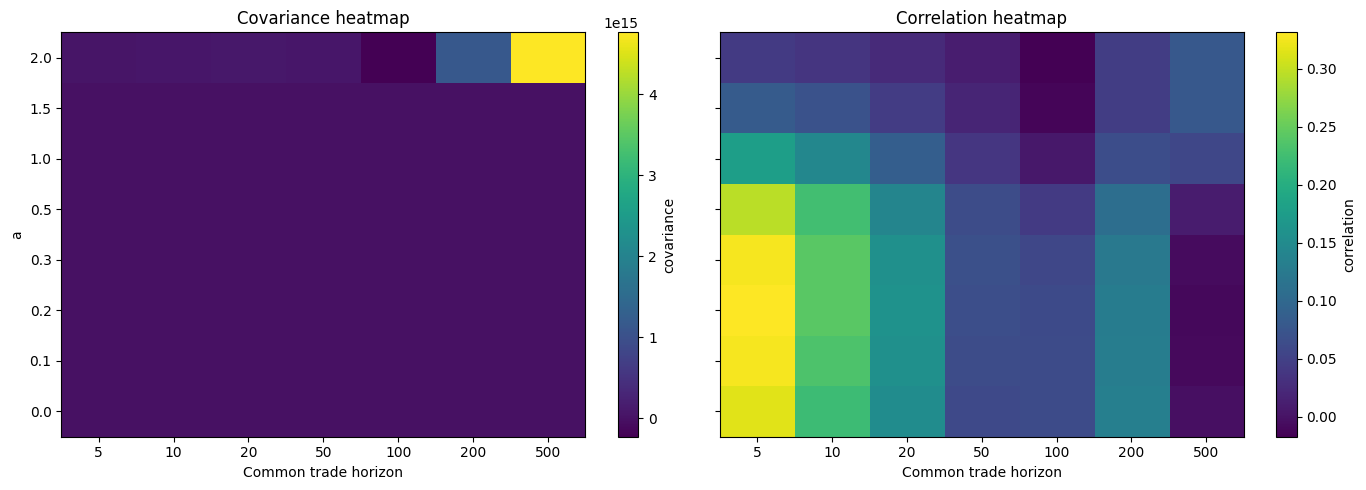

In [10]:
cov_pivot = grid_df.pivot(index="a", columns="common_horizon", values="cov")
corr_pivot = grid_df.pivot(index="a", columns="common_horizon", values="corr")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

im0 = axes[0].imshow(cov_pivot.values, aspect="auto", origin="lower")
axes[0].set_title("Covariance heatmap")
axes[0].set_xticks(range(len(cov_pivot.columns)))
axes[0].set_xticklabels(cov_pivot.columns)
axes[0].set_yticks(range(len(cov_pivot.index)))
axes[0].set_yticklabels(cov_pivot.index)
axes[0].set_xlabel("Common trade horizon")
axes[0].set_ylabel("a")
fig.colorbar(im0, ax=axes[0], label="covariance")

im1 = axes[1].imshow(corr_pivot.values, aspect="auto", origin="lower")
axes[1].set_title("Correlation heatmap")
axes[1].set_xticks(range(len(corr_pivot.columns)))
axes[1].set_xticklabels(corr_pivot.columns)
axes[1].set_yticks(range(len(corr_pivot.index)))
axes[1].set_yticklabels(corr_pivot.index)
axes[1].set_xlabel("Common trade horizon")
fig.colorbar(im1, ax=axes[1], label="correlation")

plt.tight_layout()
plt.show()


## Decoupled Trade-Time Horizons

The same-horizon grid is useful as a paper-style reference, but it hides whether the best signal lookback and the best return horizon are actually the same.

This section keeps the signal in event time and lets the future return horizon vary independently:

- signal: last `T_signal` trades,
- return: next `H_return_trades` trades.

The default plots focus on `a = 0` because that is the pure trade-sign imbalance case, but the grid also computes `a = 0.3` and `a = 1.0` for comparison.

In [11]:
def build_trade_time_cov_corr_grid(
    trade_frame: pd.DataFrame,
    signal_T_list: np.ndarray,
    return_H_trade_list: np.ndarray,
    a_list: np.ndarray,
) -> pd.DataFrame:
    rows = []
    delta_cache = {int(return_H): build_trade_time_delta(trade_frame, int(return_H)) for return_H in return_H_trade_list}
    signal_cache = {
        (float(a), int(signal_T)): build_imbalance_for_signal(trade_frame, signal_T=int(signal_T), a=float(a))
        for a in a_list
        for signal_T in signal_T_list
    }

    for a in a_list:
        for signal_T in signal_T_list:
            imbalance = signal_cache[(float(a), int(signal_T))]
            for return_H in return_H_trade_list:
                summary_row = summarize_signal_delta(imbalance, delta_cache[int(return_H)])
                rows.append({
                    "a": float(a),
                    "signal_T": int(signal_T),
                    "return_H_trades": int(return_H),
                    "cov": float(summary_row["cov"]),
                    "pearson": float(summary_row["pearson"]),
                    "spearman": float(summary_row["spearman"]),
                    "corr": float(summary_row["pearson"]),
                    "n": int(summary_row["n"]),
                })
    return pd.DataFrame(rows)


trade_time_grid_df = build_trade_time_cov_corr_grid(
    trade_frame,
    signal_T_list=SIGNAL_T_LIST,
    return_H_trade_list=RETURN_H_TRADE_LIST,
    a_list=GRID_A_LIST,
)

display(trade_time_grid_df.head(20))
display(
    trade_time_grid_df
    .assign(abs_pearson=lambda df: df["pearson"].abs())
    .sort_values("abs_pearson", ascending=False)
    .head(20)
)

,a,signal_T,return_H_trades,cov,pearson,spearman,corr,n
0,0.0,20,20,0.003432,0.152777,0.155928,0.152777,25720
1,0.0,20,50,0.003776,0.129053,0.140205,0.129053,25690
2,0.0,20,100,0.003923,0.104282,0.112076,0.104282,25640
3,0.0,20,200,0.004946,0.097970,0.106873,0.097970,25540
4,0.0,20,500,0.009405,0.113911,0.127762,0.113911,25240
5,0.0,20,1000,0.003868,0.033188,0.040643,0.033188,24740
6,0.0,50,20,0.003776,0.080454,0.080938,0.080454,25690
7,0.0,50,50,0.003630,0.059384,0.070505,0.059384,25660
8,0.0,50,100,0.005102,0.064916,0.076325,0.064916,25610
9,0.0,50,200,0.007869,0.074646,0.084542,0.074646,25510


,a,signal_T,return_H_trades,cov,pearson,spearman,corr,n,abs_pearson
30,0.3,20,20,0.401569,0.157885,0.163499,0.157885,25720,0.157885
0,0.0,20,20,0.003432,0.152777,0.155928,0.152777,25720,0.152777
21,0.0,200,200,0.041231,0.132617,0.124532,0.132617,25360,0.132617
31,0.3,20,50,0.436475,0.131759,0.144319,0.131759,25690,0.131759
1,0.0,20,50,0.003776,0.129053,0.140205,0.129053,25690,0.129053
51,0.3,200,200,3.834928,0.124101,0.125966,0.124101,25360,0.124101
4,0.0,20,500,0.009405,0.113911,0.127762,0.113911,25240,0.113911
32,0.3,20,100,0.455858,0.107109,0.114966,0.107109,25640,0.107109
2,0.0,20,100,0.003923,0.104282,0.112076,0.104282,25640,0.104282
10,0.0,50,500,0.017739,0.102762,0.119076,0.102762,25210,0.102762


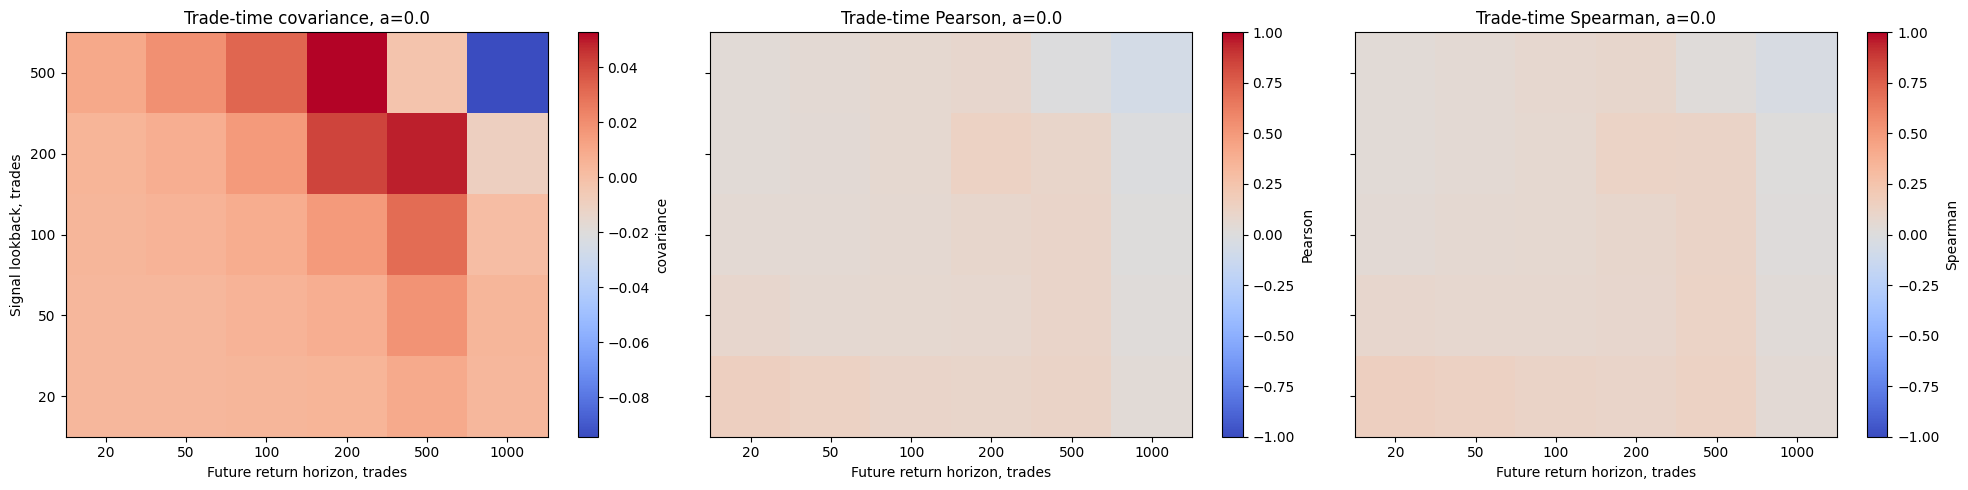

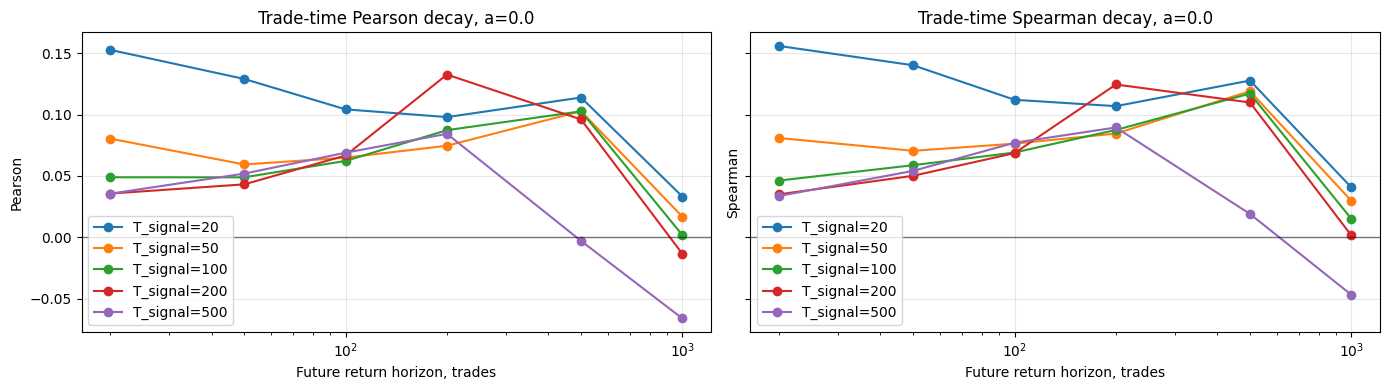

In [12]:
def plot_trade_time_grid(grid_df: pd.DataFrame, *, a: float = DEFAULT_PLOT_A) -> None:
    plot_df = grid_df[grid_df["a"] == a].copy()
    pearson_pivot = plot_df.pivot(index="signal_T", columns="return_H_trades", values="pearson").sort_index()
    spearman_pivot = plot_df.pivot(index="signal_T", columns="return_H_trades", values="spearman").sort_index()
    cov_pivot = plot_df.pivot(index="signal_T", columns="return_H_trades", values="cov").sort_index()

    fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

    im0 = axes[0].imshow(cov_pivot.values, aspect="auto", origin="lower", cmap="coolwarm")
    axes[0].set_title(f"Trade-time covariance, a={a}")
    axes[0].set_xticks(range(len(cov_pivot.columns)))
    axes[0].set_xticklabels(cov_pivot.columns)
    axes[0].set_yticks(range(len(cov_pivot.index)))
    axes[0].set_yticklabels(cov_pivot.index)
    axes[0].set_xlabel("Future return horizon, trades")
    axes[0].set_ylabel("Signal lookback, trades")
    fig.colorbar(im0, ax=axes[0], label="covariance")

    im1 = axes[1].imshow(pearson_pivot.values, aspect="auto", origin="lower", cmap="coolwarm", vmin=-1, vmax=1)
    axes[1].set_title(f"Trade-time Pearson, a={a}")
    axes[1].set_xticks(range(len(pearson_pivot.columns)))
    axes[1].set_xticklabels(pearson_pivot.columns)
    axes[1].set_yticks(range(len(pearson_pivot.index)))
    axes[1].set_yticklabels(pearson_pivot.index)
    axes[1].set_xlabel("Future return horizon, trades")
    fig.colorbar(im1, ax=axes[1], label="Pearson")

    im2 = axes[2].imshow(spearman_pivot.values, aspect="auto", origin="lower", cmap="coolwarm", vmin=-1, vmax=1)
    axes[2].set_title(f"Trade-time Spearman, a={a}")
    axes[2].set_xticks(range(len(spearman_pivot.columns)))
    axes[2].set_xticklabels(spearman_pivot.columns)
    axes[2].set_yticks(range(len(spearman_pivot.index)))
    axes[2].set_yticklabels(spearman_pivot.index)
    axes[2].set_xlabel("Future return horizon, trades")
    fig.colorbar(im2, ax=axes[2], label="Spearman")

    plt.tight_layout()
    plt.show()


def plot_trade_time_corr_lines(grid_df: pd.DataFrame, *, a: float = DEFAULT_PLOT_A) -> None:
    plot_df = grid_df[grid_df["a"] == a].copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

    for signal_T in sorted(plot_df["signal_T"].unique()):
        tmp = plot_df[plot_df["signal_T"] == signal_T].sort_values("return_H_trades")
        axes[0].plot(tmp["return_H_trades"], tmp["pearson"], marker="o", label=f"T_signal={signal_T}")
        axes[1].plot(tmp["return_H_trades"], tmp["spearman"], marker="o", label=f"T_signal={signal_T}")

    for ax, title, ylabel in [
        (axes[0], f"Trade-time Pearson decay, a={a}", "Pearson"),
        (axes[1], f"Trade-time Spearman decay, a={a}", "Spearman"),
    ]:
        ax.set_xscale("log")
        ax.axhline(0.0, color="black", linewidth=1, alpha=0.5)
        ax.set_title(title)
        ax.set_xlabel("Future return horizon, trades")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


plot_trade_time_grid(trade_time_grid_df, a=DEFAULT_PLOT_A)
plot_trade_time_corr_lines(trade_time_grid_df, a=DEFAULT_PLOT_A)

## Clock-Time Future Returns

This section keeps the same event-time signal but measures the future price move in wall-clock time.

For each trade timestamp `t`, the notebook finds the first top-of-book midprice at or after `t + horizon` and computes the log return from the current trade-aligned midprice to that future midprice.

This is the first place where horizons like `30s`, `5min`, and `60min` enter the analysis.

In [13]:
def build_clock_time_cov_corr_grid(
    trade_frame: pd.DataFrame,
    book_mid_frame: pd.DataFrame,
    signal_T_list: np.ndarray,
    return_H_clock_list: list[str],
    a_list: np.ndarray,
) -> pd.DataFrame:
    rows = []
    delta_cache = {
        return_horizon_label(horizon): build_clock_time_delta(trade_frame, book_mid_frame, horizon)
        for horizon in return_H_clock_list
    }
    signal_cache = {
        (float(a), int(signal_T)): build_imbalance_for_signal(trade_frame, signal_T=int(signal_T), a=float(a))
        for a in a_list
        for signal_T in signal_T_list
    }

    for a in a_list:
        for signal_T in signal_T_list:
            imbalance = signal_cache[(float(a), int(signal_T))]
            for horizon_label, delta in delta_cache.items():
                summary_row = summarize_signal_delta(imbalance, delta)
                horizon_td = pd.to_timedelta(horizon_label)
                rows.append({
                    "a": float(a),
                    "signal_T": int(signal_T),
                    "return_H_clock": horizon_label,
                    "return_H_seconds": float(horizon_td.total_seconds()),
                    "cov": float(summary_row["cov"]),
                    "pearson": float(summary_row["pearson"]),
                    "spearman": float(summary_row["spearman"]),
                    "corr": float(summary_row["pearson"]),
                    "n": int(summary_row["n"]),
                })
    return pd.DataFrame(rows)


clock_time_grid_df = build_clock_time_cov_corr_grid(
    trade_frame,
    book_mid_frame=book_mid_frame,
    signal_T_list=SIGNAL_T_LIST,
    return_H_clock_list=RETURN_H_CLOCK_LIST,
    a_list=GRID_A_LIST,
)

display(clock_time_grid_df.head(20))
display(
    clock_time_grid_df
    .assign(abs_pearson=lambda df: df["pearson"].abs())
    .sort_values("abs_pearson", ascending=False)
    .head(20)
)

,a,signal_T,return_H_clock,return_H_seconds,cov,pearson,spearman,corr,n
0,0.0,20,1s,1.0,0.009078,0.372302,0.364349,0.372302,25740
1,0.0,20,2s,2.0,0.008201,0.336183,0.326117,0.336183,25740
2,0.0,20,5s,5.0,0.008090,0.322979,0.313867,0.322979,25740
3,0.0,20,10s,10.0,0.006518,0.266738,0.258944,0.266738,25740
4,0.0,20,15s,15.0,0.006775,0.268925,0.266171,0.268925,25740
5,0.0,20,30s,30.0,0.006160,0.227222,0.240134,0.227222,25740
6,0.0,20,1min,60.0,0.006246,0.208960,0.215713,0.208960,25740
7,0.0,20,5min,300.0,0.006954,0.156070,0.165842,0.156070,25696
8,0.0,20,15min,900.0,0.006125,0.094333,0.104131,0.094333,25581
9,0.0,20,30min,1800.0,0.007723,0.088183,0.108094,0.088183,25516


,a,signal_T,return_H_clock,return_H_seconds,cov,pearson,spearman,corr,n,abs_pearson
0,0.0,20,1s,1.0,0.009078,0.372302,0.364349,0.372302,25740,0.372302
1,0.0,20,2s,2.0,0.008201,0.336183,0.326117,0.336183,25740,0.336183
2,0.0,20,5s,5.0,0.008090,0.322979,0.313867,0.322979,25740,0.322979
55,0.3,20,1s,1.0,0.877999,0.317900,0.321598,0.317900,25740,0.317900
56,0.3,20,2s,2.0,0.811749,0.293769,0.295166,0.293769,25740,0.293769
57,0.3,20,5s,5.0,0.820442,0.289175,0.289808,0.289175,25740,0.289175
11,0.0,50,1s,1.0,0.014480,0.284367,0.273327,0.284367,25710,0.284367
4,0.0,20,15s,15.0,0.006775,0.268925,0.266171,0.268925,25740,0.268925
3,0.0,20,10s,10.0,0.006518,0.266738,0.258944,0.266738,25740,0.266738
58,0.3,20,10s,10.0,0.697778,0.252098,0.251616,0.252098,25740,0.252098


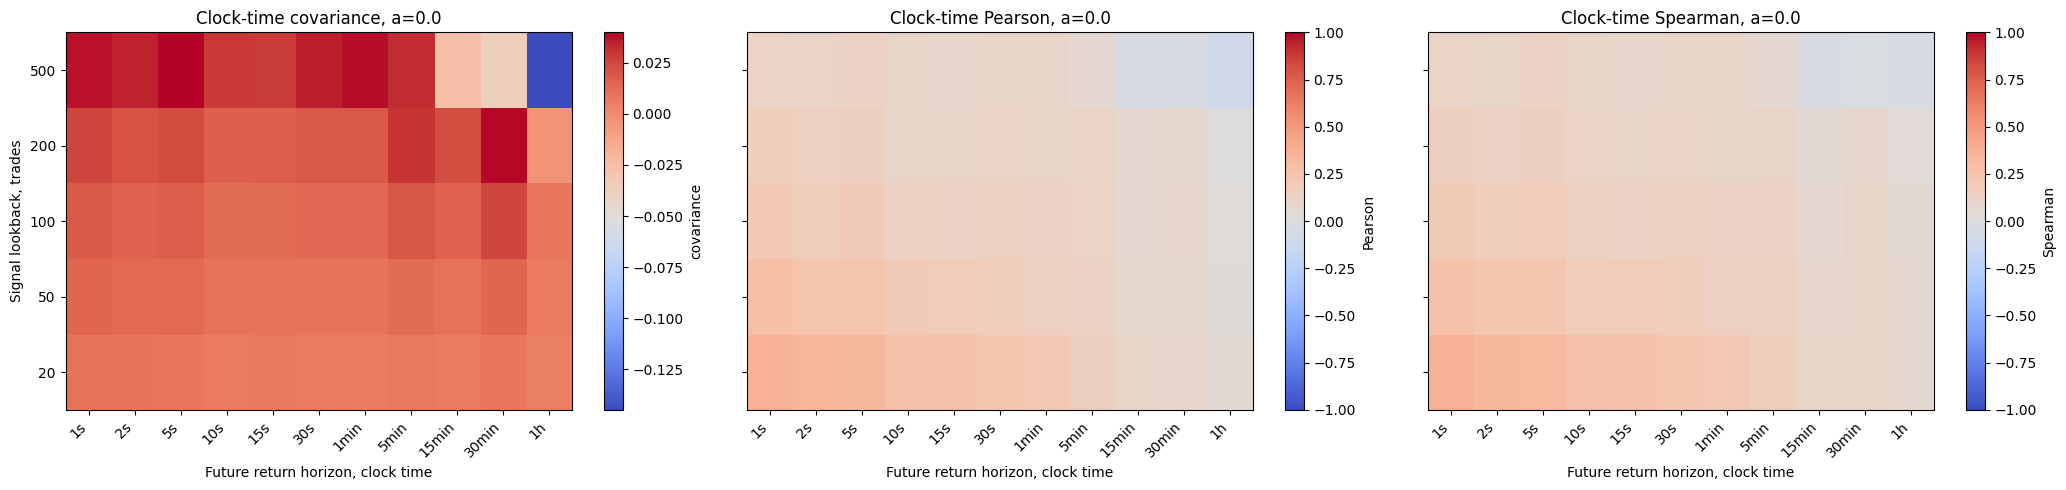

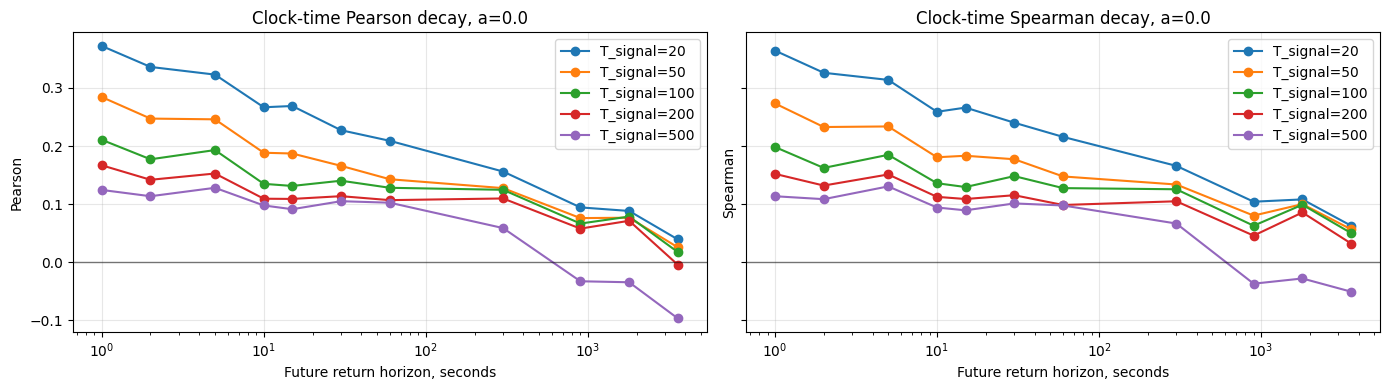

In [14]:
def plot_clock_time_grid(grid_df: pd.DataFrame, *, a: float = DEFAULT_PLOT_A) -> None:
    plot_df = grid_df[grid_df["a"] == a].copy().sort_values("return_H_seconds")
    horizon_order = plot_df[["return_H_clock", "return_H_seconds"]].drop_duplicates().sort_values("return_H_seconds")["return_H_clock"].tolist()
    pearson_pivot = plot_df.pivot(index="signal_T", columns="return_H_clock", values="pearson").reindex(columns=horizon_order).sort_index()
    spearman_pivot = plot_df.pivot(index="signal_T", columns="return_H_clock", values="spearman").reindex(columns=horizon_order).sort_index()
    cov_pivot = plot_df.pivot(index="signal_T", columns="return_H_clock", values="cov").reindex(columns=horizon_order).sort_index()

    fig, axes = plt.subplots(1, 3, figsize=(21, 5), sharey=True)

    im0 = axes[0].imshow(cov_pivot.values, aspect="auto", origin="lower", cmap="coolwarm")
    axes[0].set_title(f"Clock-time covariance, a={a}")
    axes[0].set_xticks(range(len(cov_pivot.columns)))
    axes[0].set_xticklabels(cov_pivot.columns, rotation=45, ha="right")
    axes[0].set_yticks(range(len(cov_pivot.index)))
    axes[0].set_yticklabels(cov_pivot.index)
    axes[0].set_xlabel("Future return horizon, clock time")
    axes[0].set_ylabel("Signal lookback, trades")
    fig.colorbar(im0, ax=axes[0], label="covariance")

    im1 = axes[1].imshow(pearson_pivot.values, aspect="auto", origin="lower", cmap="coolwarm", vmin=-1, vmax=1)
    axes[1].set_title(f"Clock-time Pearson, a={a}")
    axes[1].set_xticks(range(len(pearson_pivot.columns)))
    axes[1].set_xticklabels(pearson_pivot.columns, rotation=45, ha="right")
    axes[1].set_yticks(range(len(pearson_pivot.index)))
    axes[1].set_yticklabels(pearson_pivot.index)
    axes[1].set_xlabel("Future return horizon, clock time")
    fig.colorbar(im1, ax=axes[1], label="Pearson")

    im2 = axes[2].imshow(spearman_pivot.values, aspect="auto", origin="lower", cmap="coolwarm", vmin=-1, vmax=1)
    axes[2].set_title(f"Clock-time Spearman, a={a}")
    axes[2].set_xticks(range(len(spearman_pivot.columns)))
    axes[2].set_xticklabels(spearman_pivot.columns, rotation=45, ha="right")
    axes[2].set_yticks(range(len(spearman_pivot.index)))
    axes[2].set_yticklabels(spearman_pivot.index)
    axes[2].set_xlabel("Future return horizon, clock time")
    fig.colorbar(im2, ax=axes[2], label="Spearman")

    plt.tight_layout()
    plt.show()


def plot_clock_time_corr_lines(grid_df: pd.DataFrame, *, a: float = DEFAULT_PLOT_A) -> None:
    plot_df = grid_df[grid_df["a"] == a].copy().sort_values("return_H_seconds")
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

    for signal_T in sorted(plot_df["signal_T"].unique()):
        tmp = plot_df[plot_df["signal_T"] == signal_T].sort_values("return_H_seconds")
        axes[0].plot(tmp["return_H_seconds"], tmp["pearson"], marker="o", label=f"T_signal={signal_T}")
        axes[1].plot(tmp["return_H_seconds"], tmp["spearman"], marker="o", label=f"T_signal={signal_T}")

    for ax, title, ylabel in [
        (axes[0], f"Clock-time Pearson decay, a={a}", "Pearson"),
        (axes[1], f"Clock-time Spearman decay, a={a}", "Spearman"),
    ]:
        ax.set_xscale("log")
        ax.axhline(0.0, color="black", linewidth=1, alpha=0.5)
        ax.set_title(title)
        ax.set_xlabel("Future return horizon, seconds")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


plot_clock_time_grid(clock_time_grid_df, a=DEFAULT_PLOT_A)
plot_clock_time_corr_lines(clock_time_grid_df, a=DEFAULT_PLOT_A)

## Reading The Extended Grids

Use the same-horizon grid as the paper-style baseline.

Use the decoupled trade-time grid to ask whether a signal over the last `N` trades is most related to the next `N` trades or to a different future trade count.

Use the clock-time grid for execution-style questions, where the future return horizon is wall-clock time. This is the more relevant view for long-horizon signal work because `30s`, `5min`, and `60min` are comparable across high- and low-activity periods.

The current notebook still uses an event-time signal. A later notebook can add clock-time signal windows if the clock-time return grid looks promising.

Pearson and Spearman are both computed on the same raw signal/return pairs; only the summary statistic changes.